<a href="https://colab.research.google.com/github/94Akriti/DL-ML-USING-PYTORCH/blob/main/PyTorch_Workflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1: "data (prepare and load)",

2: "build model",

3: "fitting the model to data (training)",

4: "making predictions and evaluating a model (inference)",

5: "saving and loading a model",

6: "putting it all together"

In [ ]:
import torch
from torch import nn # all building blocks needed for neural networks in pytorch
import matplotlib
import matplotlib.pyplot as plt

torch.__version__

'2.11.0+cu128'

### Data Preparing and Loading

Data can be anytype like audio,images,videos,DNA,Text,Excel spreadsheets,etc


ML is a game of two parts:



1.   Get data into a numerical representation.
2.   Build a model to learn patterns in that numerical representation.

To do this we will be using Linear regression for pattern plotting with known parameters

Y = a + bx



In [ ]:
# Create known parameters
weight = 0.7
bias = 0.3

# Data
start = 0
end = 1
step = 0.02
X = torch.arange(start,end,step).unsqueeze(dim = 1)

# model
y = weight * X + bias

#output
X[:10],y[:10]

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840],
         [0.3980],
         [0.4120],
         [0.4260]]))

### Splitting datat into training and testing sets


In [ ]:
# Create a train/test split

train_split = int(0.8 * len(X))

X_train, y_train = X[:train_split],y[:train_split]

X_test,y_test = X[train_split:],y[train_split:]

len(X_train),len(y_train),len(X_test),len(y_test)

(40, 40, 10, 10)

In [ ]:
def plot_predictions(train_data = X_train,train_labels = y_train,test_data = X_test,test_label = y_test,predictions = None):
  #plots training data, test data and compares predictions

  plt.figure(figsize =(10,7) )

  #plot training data in blue
  plt.scatter(train_data, train_labels, c = "b", s = 4, label ="Training data")

  #plot test data in green
  plt.scatter(test_data, test_label, c = "g", s = 4, label ="Testing data")

  #are there predictions
  if predictions is not None:
    # plot yhe predictions if any
    plt.scatter(test_data, predictions, c = "r", s = 4, label ="Predictions")

  #show the legend
  plt.legend(prop = {"size": 14})

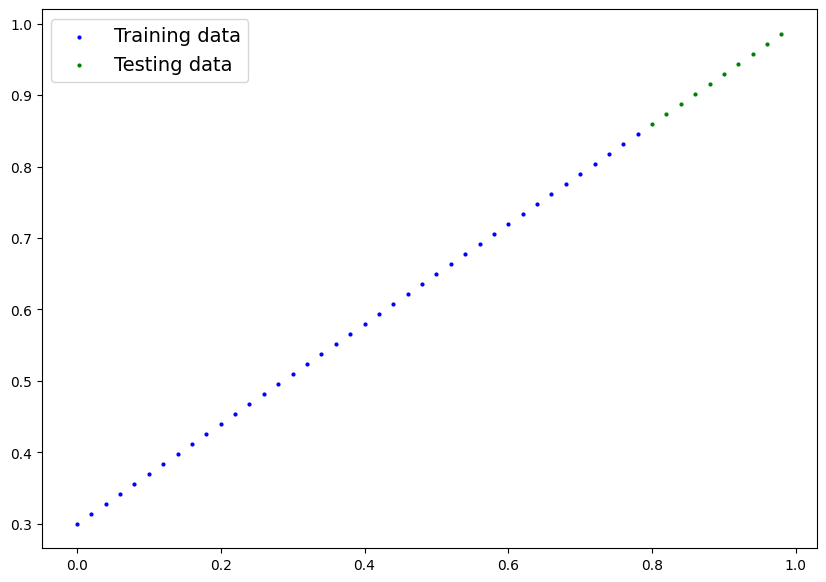

In [ ]:
#plot graph
plot_predictions()

### Build Model

Model to represent Linear Regression

To Do:
1. Start at random values of weight and bias
2. Look at training data and adjust the random values to better represent (or get closer to) the ideal values (the weight and bias values we used to create the data)

Using two main algorithms:

1. Gradient decent
2. Backpropagation



In [ ]:
# Create linear regression model class

class LinearRegressionModel(nn.Module): # almost everything in PyTorch models inherit from nn Module
  def __init__(self):
    super().__init__()

    #initialize model parameters
    self.weights = nn.Parameter(torch.randn(1, requires_grad = True, dtype = torch.float))
    self.bias = nn.Parameter(torch.randn(1,requires_grad = True, dtype = torch.float))

    #forward method to define the computation in the model which is called everytime
  def forward(self, x:torch.Tensor) -> torch.Tensor: # x is the input data or the training data
    return self.weights * x + self.bias # linear regression formula

### PyTorch model building essentials



*   torch.nn = Contains all of the building blocks for computational graphs
*   torch.nn.Parameter = parameters required for model to try and learn, often a PyTorch layer from torch.nn will set these
*    torch.nn.Module - The base class for all neural network modules, if you subclass it, you should overwirte forward()
*   torch.optim - this where the optimizers in PyTorch that will help in gradient decent
*   def forward() - All nn.Module subclasses require a forward() method, this defines the computation that will take place on the data passed to the particular nn.Module (e.g. the linear regression formula above).



In [ ]:
# Set manual seed since nn.Parameter are randomly initialized
torch.manual_seed(42)

# Create an instance of the model (this is a subclass of nn.Module that contains nn.Parameter(s))
model_0 = LinearRegressionModel()

# Check the nn.Parameter(s) within the nn.Module subclass we created
list(model_0.parameters())

[Parameter containing:
 tensor([0.3367], requires_grad=True),
 Parameter containing:
 tensor([0.1288], requires_grad=True)]

In [ ]:
# Check the parameter values used
model_0.state_dict()

OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.1288]))])

In [ ]:
# Make predictions with model
with torch.inference_mode():
    y_preds = model_0(X_test)

# Note: in older PyTorch code you might also see torch.no_grad()
# with torch.no_grad():
#   y_preds = model_0(X_test)

In [ ]:
# Check the predictions
print(f"Number of testing samples: {len(X_test)}")
print(f"Number of predictions made: {len(y_preds)}")
print(f"Predicted values:\n{y_preds}")

Number of testing samples: 10
Number of predictions made: 10
Predicted values:
tensor([[0.3982],
        [0.4049],
        [0.4116],
        [0.4184],
        [0.4251],
        [0.4318],
        [0.4386],
        [0.4453],
        [0.4520],
        [0.4588]])


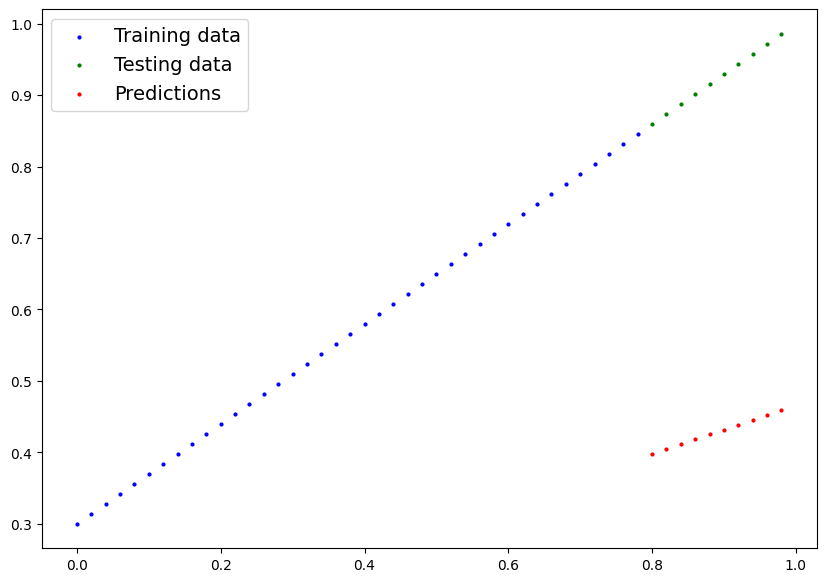

In [ ]:
plot_predictions(predictions=y_preds)

In [ ]:
y_test - y_preds

tensor([[0.4618],
        [0.4691],
        [0.4764],
        [0.4836],
        [0.4909],
        [0.4982],
        [0.5054],
        [0.5127],
        [0.5200],
        [0.5272]])

### Train Model

minimize the loss so the predictions match required output

*  Creating a loss function and optimizer in PyTorch

In [ ]:
# Create the loss function
loss_fn = nn.L1Loss() # MAE loss is same as L1Loss

# Create the optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), # parameters of target model to optimize
                            lr=0.01) # learning rate (how much the optimizer should change parameters at each step, higher=more (less stable), lower=less (might take a long time))

In [ ]:
loss_fn, optimizer

(L1Loss(),
 SGD (
 Parameter Group 0
     dampening: 0
     differentiable: False
     foreach: None
     fused: None
     lr: 0.01
     maximize: False
     momentum: 0
     nesterov: False
     weight_decay: 0
 ))

### Building a training loop

A couple of things we need in a training loop:

1. Loop through the data
2. Forward pass - It moves the data through model's forward() function. This process is known as forward propagation
3. Calculate the loss
4. Optimizer zero grad
5. Loss backward - move backwards through the network to calculate the gradient of each of the parameters of our model with rtespecxt to the loss
6. Optimizer step - uses optimizer to adjust model's parameters to try and improve the loss

In [ ]:
# list(model_0.parameters())
with torch.no_grad():
  list(model_0.parameters())

In [ ]:
torch.manual_seed(42)
# An epoch is one loop through the data
epochs = 300

epoch_count = []
loss_values = []
test_loss_values = []

# Training Model

# 1. Loop through the data
for epochs in range(epochs):
  model_0.train()

  # 2. Forward  pass
  y_pred = model_0(X_train)

  # 3. Calculate the loss
  loss = loss_fn(y_pred,y_train)

  # 4. Optimizer zero grad
  optimizer.zero_grad()

  # 5. Perform propagation on the loss with respect to the parameters of the model
  loss.backward() # all parameters should have grad = True

  # 6. Step the optimizer (perform gradient descent)
  optimizer.step()

  # Testing
  model_0.eval() # turns off settings not required for evaluations like dropout layers,batch norm layers
  with torch.inference_mode():
    test_prediction = model_0(X_test)
    test_loss = loss_fn(test_prediction,y_test)

  # Print out what's happening
  if epochs % 10 ==0:
    epoch_count.append(epochs)
    loss_values.append(loss)
    test_loss_values.append(test_loss)
    print(f"Epoch :{epochs} | Loss:{loss} | Test Loss: {test_loss}")
  # Print model state_dict()
    print(model_0.state_dict())


Epoch :0 | Loss:0.31288138031959534 | Test Loss: 0.48106518387794495
OrderedDict({'weights': tensor([0.3406]), 'bias': tensor([0.1388])})
Epoch :10 | Loss:0.1976713240146637 | Test Loss: 0.3463551998138428
OrderedDict({'weights': tensor([0.3796]), 'bias': tensor([0.2388])})
Epoch :20 | Loss:0.08908725529909134 | Test Loss: 0.21729660034179688
OrderedDict({'weights': tensor([0.4184]), 'bias': tensor([0.3333])})
Epoch :30 | Loss:0.053148526698350906 | Test Loss: 0.14464017748832703
OrderedDict({'weights': tensor([0.4512]), 'bias': tensor([0.3768])})
Epoch :40 | Loss:0.04543796554207802 | Test Loss: 0.11360953003168106
OrderedDict({'weights': tensor([0.4748]), 'bias': tensor([0.3868])})
Epoch :50 | Loss:0.04167863354086876 | Test Loss: 0.09919948130846024
OrderedDict({'weights': tensor([0.4938]), 'bias': tensor([0.3843])})
Epoch :60 | Loss:0.03818932920694351 | Test Loss: 0.08886633068323135
OrderedDict({'weights': tensor([0.5116]), 'bias': tensor([0.3788])})
Epoch :70 | Loss:0.0347608998

In [ ]:
with torch.inference_mode():
    y_preds_new = model_0(X_test)

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

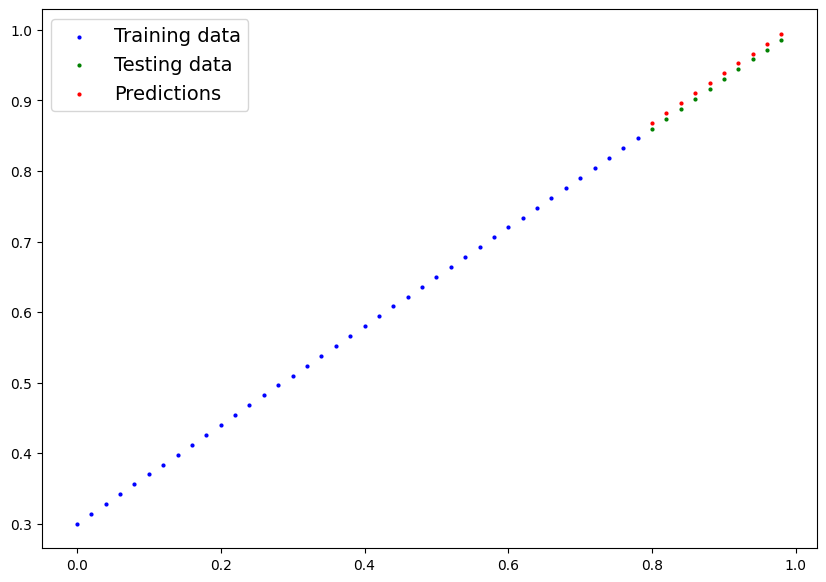

In [ ]:
plot_predictions(predictions = y_preds_new)

In [ ]:
import numpy as np
np.array(torch.tensor(loss_values).cpu().numpy()), test_loss_values, epoch_count

/tmp/ipykernel_536/3132178175.py:2: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  np.array(torch.tensor(loss_values).cpu().numpy()), test_loss_values, epoch_count


(array([0.31288138, 0.19767132, 0.08908726, 0.05314853, 0.04543797,
        0.04167863, 0.03818933, 0.0347609 , 0.03132383, 0.0278874 ,
        0.02445896, 0.02102021, 0.01758547, 0.01415539, 0.01071659,
        0.00728353, 0.00385178, 0.00893248, 0.00893248, 0.00893248,
        0.00893248, 0.00893248, 0.00893248, 0.00893248, 0.00893248,
        0.00893248, 0.00893248, 0.00893248, 0.00893248, 0.00893248],
       dtype=float32),
 [tensor(0.4811),
  tensor(0.3464),
  tensor(0.2173),
  tensor(0.1446),
  tensor(0.1136),
  tensor(0.0992),
  tensor(0.0889),
  tensor(0.0806),
  tensor(0.0723),
  tensor(0.0647),
  tensor(0.0565),
  tensor(0.0482),
  tensor(0.0406),
  tensor(0.0323),
  tensor(0.0241),
  tensor(0.0165),
  tensor(0.0082),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050),
  tensor(0.0050)],
 [0,
  10,
  20,
  30,
  40

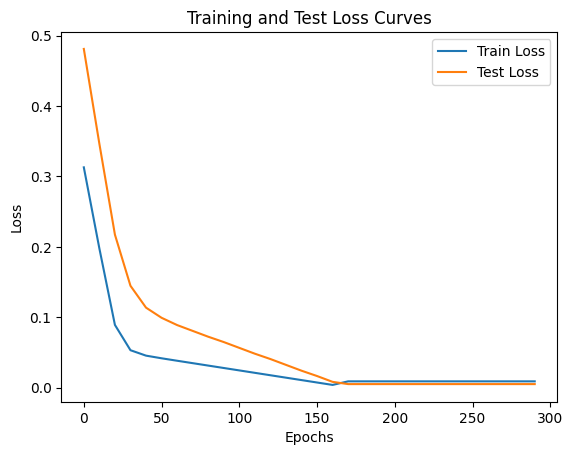

In [ ]:
#Loss curves plots
plt.plot(epoch_count, np.array(torch.tensor(loss_values).cpu().numpy()), label = "Train Loss")
plt.plot(epoch_count, test_loss_values, label = "Test Loss")
plt.title("Training and Test Loss Curves")
plt.ylabel("Loss")
plt.xlabel("Epochs")
plt.legend()

### Saving Model in Pytorch

1. torch.save()-saves the Pytorch object in PICKLE format
2. torch.load()-loads saved Pytorch model
3. torch.nn.Module.load_state_dict()-loads a saved Pytorch object in form of dictionary

In [ ]:
from pathlib import Path

# Create moddel directory
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok=True)

MODEL_NAME = "python_workflow"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH
torch.save(obj = model_0.state_dict(),
           f = MODEL_SAVE_PATH)

In [ ]:
!ls -l models

total 4
-rw-r--r-- 1 root root 1957 Jun  7 16:36 python_workflow


###Loading saved pytorch model

In [ ]:
model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# To load in a saved state_dict we need to instantiate a new instance of our model class
loaded_model_0 = LinearRegressionModel()
loaded_model_0.load_state_dict(torch.load(f = MODEL_SAVE_PATH))

<All keys matched successfully>

In [ ]:
loaded_model_0.state_dict()

OrderedDict([('weights', tensor([0.6990])), ('bias', tensor([0.3093]))])

In [ ]:
# Make some predictions with our loaded model
loaded_model_0.eval()

with torch.inference_mode():
  loaded_model_0_preds = loaded_model_0(X_test)
loaded_model_0_preds

tensor([[0.8685],
        [0.8825],
        [0.8965],
        [0.9105],
        [0.9245],
        [0.9384],
        [0.9524],
        [0.9664],
        [0.9804],
        [0.9944]])

In [ ]:
with torch.inference_mode():
    y_preds = model_0(X_test)

In [ ]:
# Compare loaded model predictions with the actual model predictions

y_preds == loaded_model_0_preds


tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

### Summarize

torch.cuda.is_avalable()
  
  Device agnostic code: check if gpus are available utilize cuda framework for gpus else utilize cpu

Data

parameters used in model to be trained and tested

we unsqueez the data while setting to reduce errors


In [ ]:
import torch
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
weight = 0.7
bias = 0.3
start = 0
end = 1
step = 0.02

X = torch.arange(start, end, step).unsqueeze(dim = 1)
y = weight * X + bias

X,y

(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200],
         [0.1400],
         [0.1600],
         [0.1800],
         [0.2000],
         [0.2200],
         [0.2400],
         [0.2600],
         [0.2800],
         [0.3000],
         [0.3200],
         [0.3400],
         [0.3600],
         [0.3800],
         [0.4000],
         [0.4200],
         [0.4400],
         [0.4600],
         [0.4800],
         [0.5000],
         [0.5200],
         [0.5400],
         [0.5600],
         [0.5800],
         [0.6000],
         [0.6200],
         [0.6400],
         [0.6600],
         [0.6800],
         [0.7000],
         [0.7200],
         [0.7400],
         [0.7600],
         [0.7800],
         [0.8000],
         [0.8200],
         [0.8400],
         [0.8600],
         [0.8800],
         [0.9000],
         [0.9200],
         [0.9400],
         [0.9600],
         [0.9800]]),
 tensor([[0.3000],
         [0.3140],
         [

In [ ]:
#Split data

train_split = int(0.8*len(X))
X_train, y_train = X[:train_split],y[:train_split]
X_test,y_test = X[train_split:], y[train_split:]

len(X_train), len(y_train), len(X_test), len(y_test)

(40, 40, 10, 10)

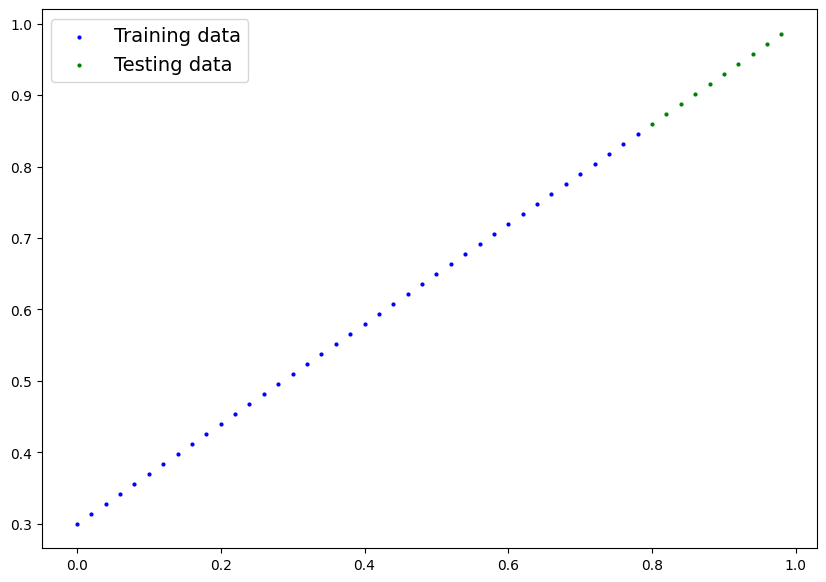

In [ ]:
plot_predictions(X_train,y_train,X_test,y_test)

### Building Pytorch Linear Regression Model using nn Module

In [ ]:
class LinearRegressionModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.linear_layer = nn.Linear(in_features = 1,
                                 out_features = 1)


  def forward (self,x:torch.Tensor) -> torch.Tensor:
    return self.linear_layer(x)

torch.manual_seed(42)
model_1 = LinearRegressionModelV1()
model_1,model_1.state_dict()

(LinearRegressionModelV1(
   (linear_layer): Linear(in_features=1, out_features=1, bias=True)
 ),
 OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
              ('linear_layer.bias', tensor([0.8300]))]))

In [ ]:
next(model_1.parameters()).device

device(type='cpu')

In [ ]:
model_1.to(device)


LinearRegressionModelV1(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
next(model_1.parameters()).device

device(type='cuda', index=0)

### Training

we require:

1. Loss function
2. Optimizer
3. Training Loop
5. Testing Loop

In [ ]:
loss_fn = nn.L1Loss()

optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.01)

In [ ]:
torch.manual_seed(42)

epochs = 300
# keep data and models on same devbice
X_train = X_train.to(device)
y_train = y_train.to(device)
X_test = X_test.to(device)
y_test = y_test.to(device)

# Training loop
for epoch in range (epochs):
  model_1.train()

  y_pred = model_1(X_train)

  loss = loss_fn(y_pred,y_train)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    test_pred = model_1(X_test)
    test_loss = loss_fn(test_pred,y_test)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss} | Test Loss: {test_loss}")
    print(model_1.state_dict())

Epoch: 0 | Loss: 0.5551779270172119 | Test Loss: 0.5739762187004089
OrderedDict({'linear_layer.weight': tensor([[0.7606]], device='cuda:0'), 'linear_layer.bias': tensor([0.8200], device='cuda:0')})
Epoch: 10 | Loss: 0.4399681091308594 | Test Loss: 0.4392664134502411
OrderedDict({'linear_layer.weight': tensor([[0.7216]], device='cuda:0'), 'linear_layer.bias': tensor([0.7200], device='cuda:0')})
Epoch: 20 | Loss: 0.3247582018375397 | Test Loss: 0.30455657839775085
OrderedDict({'linear_layer.weight': tensor([[0.6826]], device='cuda:0'), 'linear_layer.bias': tensor([0.6200], device='cuda:0')})
Epoch: 30 | Loss: 0.20954833924770355 | Test Loss: 0.16984669864177704
OrderedDict({'linear_layer.weight': tensor([[0.6436]], device='cuda:0'), 'linear_layer.bias': tensor([0.5200], device='cuda:0')})
Epoch: 40 | Loss: 0.09433844685554504 | Test Loss: 0.03513690456748009
OrderedDict({'linear_layer.weight': tensor([[0.6046]], device='cuda:0'), 'linear_layer.bias': tensor([0.4200], device='cuda:0')})
E

In [ ]:
model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

In [ ]:
weight, bias

(0.7, 0.3)

### Prediction plots

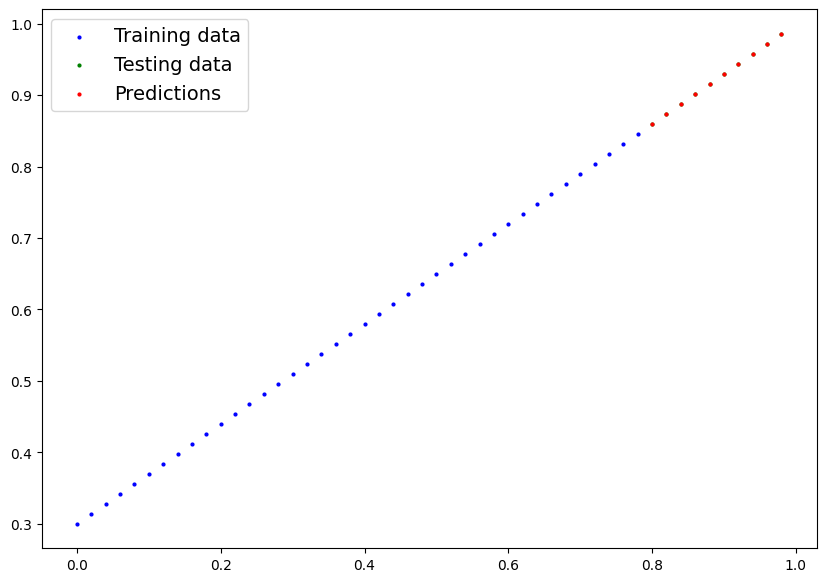

In [ ]:
model_1.eval()

with torch.inference_mode():
  y_preds = model_1(X_test)

plot_predictions(predictions = y_preds.cpu())

### Saving and loading Pytorch model

In [ ]:
from pathlib import Path

MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents = True, exist_ok = True)

MODEL_NAME = "pytorch_workflow_summary.pth"
MODEL_SAVE_PATH = MODEL_PATH / MODEL_NAME

MODEL_SAVE_PATH
torch.save(obj = model_1.state_dict(),
           f = MODEL_SAVE_PATH)
loaded_model_1 = LinearRegressionModelV1()
loaded_model_1.load_state_dict(torch.load(f = MODEL_SAVE_PATH))
loaded_model_1.to(device)

LinearRegressionModelV1(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)

In [ ]:
loaded_model_1.state_dict()

OrderedDict([('linear_layer.weight', tensor([[0.6968]], device='cuda:0')),
             ('linear_layer.bias', tensor([0.3025], device='cuda:0'))])

### Evaluating loaded model

In [ ]:
loaded_model_1.eval()

with torch.inference_mode():
  loaded_model_1_predictions = loaded_model_1(X_test)

y_preds == loaded_model_1_predictions

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]], device='cuda:0')

### Neural Network Classification with Pytorch

Classification is a problem of predicting whether one thing or another commonly binary classification or it can be multiple things prediction

## Data preparation

In [3]:
import sklearn
from sklearn.datasets import make_circles

# Make 100 samples
n_samples = 1000

# Create circles
X,y = make_circles(n_samples,noise = 0.03,random_state = 42)

In [4]:
len(X),len(y)

(1000, 1000)

In [5]:
# Make Dataframe of crcle data
import pandas as pd
circles = pd.DataFrame({"X1": X[:,0],
                        "X2": X[:,1],
                        "label": y})
circles.head(10)

,X1,X2,label
0,0.754246,0.231481,1
1,-0.756159,0.153259,1
2,-0.815392,0.173282,1
3,-0.393731,0.692883,1
4,0.442208,-0.896723,0
5,-0.479646,0.676435,1
6,-0.013648,0.803349,1
7,0.771513,0.147760,1
8,-0.169322,-0.793456,1
9,-0.121486,1.021509,0


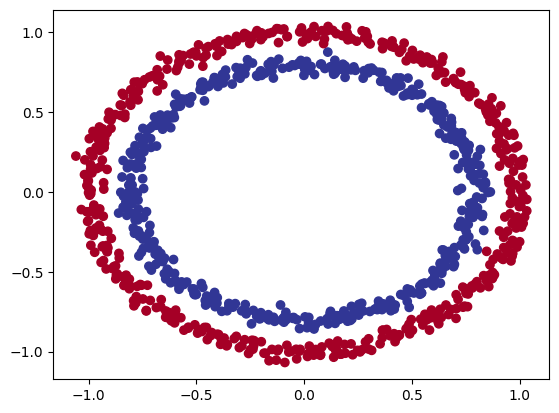

In [6]:
# plotting the data for visualization
import matplotlib.pyplot as plt
plt.scatter(x = X[:,0],
            y = X[:,1],
            c = y,
            cmap = plt.cm.RdYlBu);


### Checking input and output shape

In [7]:
X.shape,y.shape

((1000, 2), (1000,))

In [8]:
X

array([[ 0.75424625,  0.23148074],
       [-0.75615888,  0.15325888],
       [-0.81539193,  0.17328203],
       ...,
       [-0.13690036, -0.81001183],
       [ 0.67036156, -0.76750154],
       [ 0.28105665,  0.96382443]])

In [9]:
# View the first example of features and labels

X_sample = X[0]
y_sample = y[0]

print(f"Values for one sample of X:{X_sample} and the same of y:{y_sample}")
print(f"Shapes for one smaple of X:{X_sample.shape} and the same for y:{y_sample.shape}")

Values for one sample of X:[0.75424625 0.23148074] and the same of y:1
Shapes for one smaple of X:(2,) and the same for y:()


In [10]:
import torch
torch.__version__

'2.11.0+cu128'

In [11]:
type(X), X.dtype

(numpy.ndarray, dtype('float64'))

In [12]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

In [13]:
X.dtype,y.dtype

(torch.float32, torch.float32)

In [14]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size= 0.2,random_state = 42)

In [15]:
len(X_train),len(X_test),len(y_train),len(y_test)

(800, 200, 800, 200)

### Building a model

Let's build a model to classify red and blue dots

To do so we want to:

1. Setup device aonistic code so our code will run on an accelerator (GPU) if there is one available

2. Construct a model class by subclassing nn.Module

3. Define a loss function and optimizer

4. Create a training and testing loop

In [17]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

now we construct model subclassing nn.Module

1. Subclaass nn.Module
2. Create 2 nn.Linear layers capable of handling the shapes of our data
3. Define a forward() methof that outlines the forward pass
4. Instantiate an instance of our model class and send it to target device

In [23]:
from sklearn import datasets
class CircleModelV0(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2, out_features = 5)
    self.layer_2 = nn.Linear(in_features = 5,out_features = 1)
  def forward(self,x):
    return self.layer_2(self.layer_1(x))

model_0 = CircleModelV0().to(device)
model_0

CircleModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [67]:
# Lets replicate the model using nn.Sequential()

model_0 = nn.Sequential(
    nn.Linear(in_features = 2, out_features = 5),
    nn.Linear(in_features = 5, out_features = 1)
).to(device)

model_0

Sequential(
  (0): Linear(in_features=2, out_features=5, bias=True)
  (1): Linear(in_features=5, out_features=1, bias=True)
)

In [25]:
model_0.state_dict()

OrderedDict([('0.weight',
              tensor([[-0.6968,  0.1286],
                      [-0.6971, -0.3564],
                      [-0.1180,  0.0771],
                      [ 0.1806, -0.3227],
                      [ 0.5401,  0.6781]], device='cuda:0')),
             ('0.bias',
              tensor([0.0127, 0.5950, 0.5741, 0.5163, 0.2232], device='cuda:0')),
             ('1.weight',
              tensor([[0.3225, 0.2744, 0.4383, 0.2627, 0.0383]], device='cuda:0')),
             ('1.bias', tensor([-0.1174], device='cuda:0'))])

In [32]:
with torch.inference_mode():
  untrained_preds = model_0(X_test.to(device))
untrained_preds

tensor([[0.5401],
        [0.3615],
        [0.7522],
        [0.4811],
        [0.3454],
        [0.2395],
        [0.0589],
        [0.0293],
        [0.7690],
        [0.3450],
        [0.5696],
        [0.4735],
        [0.0282],
        [0.7260],
        [0.8300],
        [0.1444],
        [0.2367],
        [0.6608],
        [0.6330],
        [0.7406],
        [0.3604],
        [0.0604],
        [0.6778],
        [0.7328],
        [0.1306],
        [0.0588],
        [0.6179],
        [0.1447],
        [0.8619],
        [0.6630],
        [0.1598],
        [0.1460],
        [0.5379],
        [0.4810],
        [0.5763],
        [0.3330],
        [0.4835],
        [0.7401],
        [0.5495],
        [0.7007],
        [0.6986],
        [0.7756],
        [0.2353],
        [0.3511],
        [0.5342],
        [0.3055],
        [0.2840],
        [0.3671],
        [0.3667],
        [0.2829],
        [0.4945],
        [0.5257],
        [0.1189],
        [0.4083],
        [0.1275],
        [0

In [34]:
print(f"length of predictions: {len(untrained_preds)}, shape of preddictions: {untrained_preds.shape}")
print(f"length  of test samples: {len(X_test)}, shape of samples: {X_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 labelsy_test:\n{X_test[:10]}")

length of predictions: 200, shape of preddictions: torch.Size([200, 1])
length  of test samples: 200, shape of samples: torch.Size([200, 2])

First 10 predictions:
tensor([[0.5401],
        [0.3615],
        [0.7522],
        [0.4811],
        [0.3454],
        [0.2395],
        [0.0589],
        [0.0293],
        [0.7690],
        [0.3450]], device='cuda:0')

First 10 labelsy_test:
tensor([[-0.3752,  0.6827],
        [ 0.0154,  0.9600],
        [-0.7028, -0.3147],
        [-0.2853,  0.9664],
        [ 0.4024, -0.7438],
        [ 0.6323, -0.5711],
        [ 0.8561,  0.5499],
        [ 1.0034,  0.1903],
        [-0.7489, -0.2951],
        [ 0.0538,  0.9739]])


### Setup a loss function and Optimiser

depending upon the problem nn contains set of loss functions for example for regression we can use MSE or MAE

for classification we can use binary cross ebtropy or catagorical cross entropy

Optimizers are formed to reduced the loss, comonly use optimizer is SGD and Adam

For the Circles classification we are using torch.nn.BCWithLogitsoss() loss function

In [35]:
#Setup loss function
# loss_fn = nn.BCELoss()
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_0.parameters(),
                            lr = 0.1)


In [36]:
def accuracy_fn(y_true,y_pred):
  correct = torch.eq(y_true,y_pred).sum().item()
  acc = (correct/len(y_pred))*100
  return acc

### Train Model

1. Forward pass
2. Calculate Loss
3. Optimier Gradient set to zero
4. Loss backward
5. Optimizer step gradient descent


### Going from raw logits -> prediction probabilities -> prediction labels

our model outputs are going to be raw logits

We can convert these logits into prediction probabilites by passing them through activation function sigmoid in case of binary classification and softmax for multiclass classification

Then we can convert our model prediction probabilities into prediction labels by rounding them off

In [37]:
model_0.eval()
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))[:5]
y_logits

tensor([[0.5401],
        [0.3615],
        [0.7522],
        [0.4811],
        [0.3454]], device='cuda:0')

## predictions -> prediction pobabilities using sigmoid as our Activation function

if y_preds_prob is >= 0.5 then label of our probability  = 1 else 0

In [38]:
y_preds_probs = torch.sigmoid(y_logits)
y_preds_probs

tensor([[0.6318],
        [0.5894],
        [0.6797],
        [0.6180],
        [0.5855]], device='cuda:0')

In [39]:
# Find the predicted labels

y_preds = torch.round(y_preds_probs)

y_preds_labels = torch.round(torch.sigmoid(model_0(X_test.to(device))[:5]))

# check for equality

print(torch.eq(y_preds.squeeze(),y_preds_labels.squeeze()))

# Get rid of extra dimension

y_preds.squeeze()

tensor([True, True, True, True, True], device='cuda:0')


tensor([1., 1., 1., 1., 1.], device='cuda:0')

In [40]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

### Building training and testing loop

In [58]:
device

'cuda'

In [69]:
torch.cuda.manual_seed(42)

epochs = 1000
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

In [70]:
X_test.device,y_logits.device

(device(type='cuda', index=0), device(type='cuda', index=0))

In [71]:
for epoch in range(epochs):
  # Train the model
  model_0.train()

  # Forward pass
  y_logits = model_0(X_train).squeeze()
  #raw logits -> pred probab -> pred labels
  y_pred = torch.round(torch.sigmoid(y_logits))

  # Calculate loss function
  # If we use BCELoss it expects prediction probabilities as input
  # loss = loss_fn(torch.sigmoid(y_logits),y_train)

  loss = loss_fn(y_logits,y_train)

  # Calculate accuracy
  acc = accuracy_fn(y_true = y_train,
                    y_pred = y_pred)

  # Optimizer zero grad
  optimizer.zero_grad()
  loss.backward()
  optimizer.step()

  # Testing

  model_0.eval()
  with torch.inference_mode():
    #forward pass
    test_logits = model_0(X_test).squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))

    # Calculate test loss
    test_loss = loss_fn(test_logits,
                        y_test)

    # Calculate accuracy
    test_acc = accuracy_fn(y_true = y_test,
                            y_pred = test_pred)

    if epoch % 10 == 0:
      print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 10 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 20 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 30 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 40 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 50 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 60 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 70 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 80 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 90 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 100 | Loss: 0.69557 | Accuracy: 47.25% | Test Loss: 0.69194 | Test Accuracy: 53.50%
Epoch: 110

### Make predictions and evaluate the model

For the metrics it looks the model isn't learning so we will inspect by visualizing what is going on

To do so we will use plot_decision_boundary() function

In [72]:
import requests
from pathlib import Path

if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Download helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py","wb") as f:
    f.write(request.content)

from helper_functions import plot_predictions,plot_decision_boundary


helper_functions.py already exists, skipping download


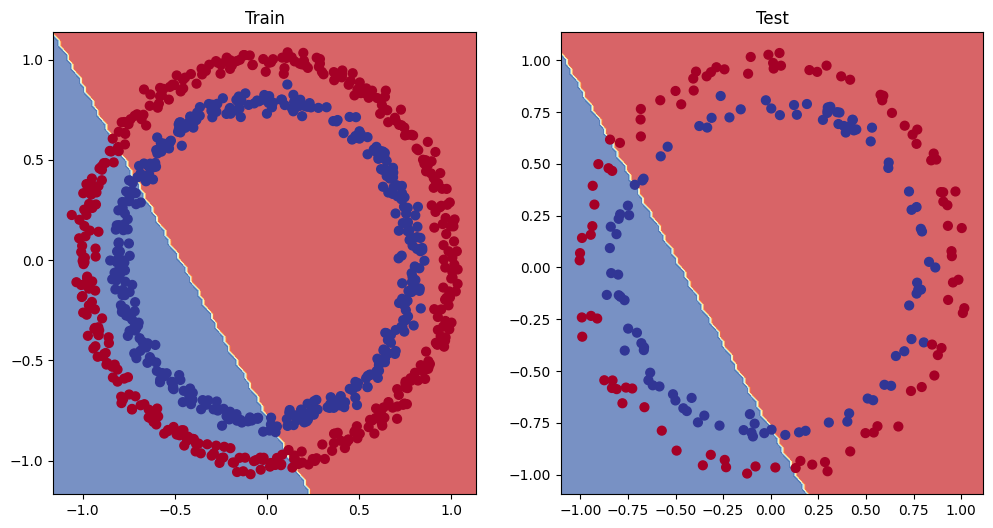

In [73]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_0,X_train,y_train)
plt.subplot(1,2,2)
plt.title("Test")
plot_decision_boundary(model_0,X_test,y_test)

### Improving a model

* Add mode layers and give the model time to learn

* Add mode hidden layers go from 5 hidden layers to 10 hidden layers

* Fit for longer

* Changing the activation function

* Changes then learning rate

* Change the loss function

In [97]:
class CircleModelV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features = 2,out_features = 10)
    self.layer_2 = nn.Linear(in_features = 10,out_features = 10)
    self.layer_3 = nn.Linear(in_features = 10,out_features = 1)

  def forward(self,x):
    # z = self.layer_1(x)
    # # z = torch.relu(z)
    # z = self.layer_2(z)
    # # z = torch.relu(z)
    # z = self.layer_3(z)
    return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = CircleModelV1()
model_1

CircleModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [90]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.5406,  0.5869],
                      [-0.1657,  0.6496],
                      [-0.1549,  0.1427],
                      [-0.3443,  0.4153],
                      [ 0.6233, -0.5188],
                      [ 0.6146,  0.1323],
                      [ 0.5224,  0.0958],
                      [ 0.3410, -0.0998],
                      [ 0.5451,  0.1045],
                      [-0.3301,  0.1802]])),
             ('layer_1.bias',
              tensor([-0.3258, -0.0829, -0.2872,  0.4691, -0.5582, -0.3260, -0.1997, -0.4252,
                       0.0667, -0.6984])),
             ('layer_2.weight',
              tensor([[ 0.2856, -0.2686,  0.2441,  0.0526, -0.1027,  0.1954,  0.0493,  0.2555,
                        0.0346, -0.0997],
                      [ 0.0850, -0.0858,  0.1331,  0.2823,  0.1828, -0.1382,  0.1825,  0.0566,
                        0.1606, -0.1927],
                      [-0.3130, -0.1222, -0.2426,  0.2595,  0.0911,  0.1

In [91]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params = model_1.parameters(),
                            lr = 0.1)

In [92]:

X_train,y_train = X_train.to(device),y_train.to(device)
X_test,y_test = X_test.to(device),y_test.to(device)

In [98]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)

epochs = 1000
# Move model to target device
model_1.to(device)
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)

for epoch in range(epochs):

  model_1.train()
  # Adjust model output to match the target shape for binary classification
  y_logits = model_1(X_train).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  loss = loss_fn(y_logits,y_train)

  acc = accuracy_fn(y_true = y_train, y_pred = y_preds)

  optimizer.zero_grad()

  loss.backward()

  optimizer.step()

  model_1.eval()

  with torch.inference_mode():
    # Adjust model output for BCEWithLogitsLoss (assuming first feature is the relevant logit)
    test_logits = model_1(X_test)[:, 0].squeeze()
    test_pred = torch.round(torch.sigmoid(test_logits))
    test_loss = loss_fn(test_logits,
                        y_test)

    test_acc = accuracy_fn(y_true = y_test,y_pred = test_pred)

  if epoch % 100 ==0:
    print(f"Epoch: {epoch} | Loss = {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 100 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 200 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 300 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 400 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 500 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 600 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 700 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 800 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%
Epoch: 900 | Loss = 0.69396 | Accuracy: 50.88% | Test Loss: 0.69261 | Test Accuracy: 51.00%


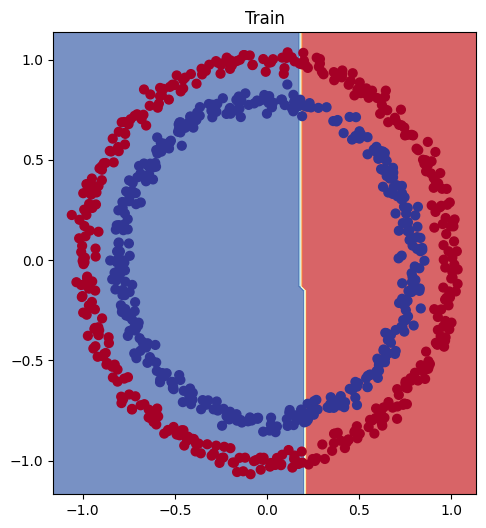

In [99]:
plt.figure(figsize = (12,6))
plt.subplot(1,2,1)
plt.title("Train")
plot_decision_boundary(model_1,X_train,y_train)